# Reto sesion 3
## Las propiedades topológicas de los datos

In [1]:
# ============================================================
# Librerías y configuración
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# TDA
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve
from gtda.plotting import plot_diagram

# Dimensión intrínseca
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import MDS

# Visualización
import plotly.graph_objects as go
import plotly.express as px

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Librerías cargadas correctamente")

# ============================================================
# Cargar datos
# ============================================================
df = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])
precios = df['WPUSI01102B'].values.astype(float)
fechas = df['observation_date'].values

print(f"Total de registros: {len(precios)}")
print(f"Periodo: {fechas[0]} a {fechas[-1]}")

✅ Librerías cargadas correctamente
Total de registros: 215
Periodo: 2008-06-01T00:00:00.000000 a 2026-04-01T00:00:00.000000


📊 SUBPERIODOS DEFINIDOS:
   Global (2008-2026): 215 meses
   2008-2012 (Crisis): 55 meses
   2013-2019 (Estable): 84 meses
   2020-2021 (Pandemia): 24 meses
   2022-2026 (Post-pandemia): 52 meses


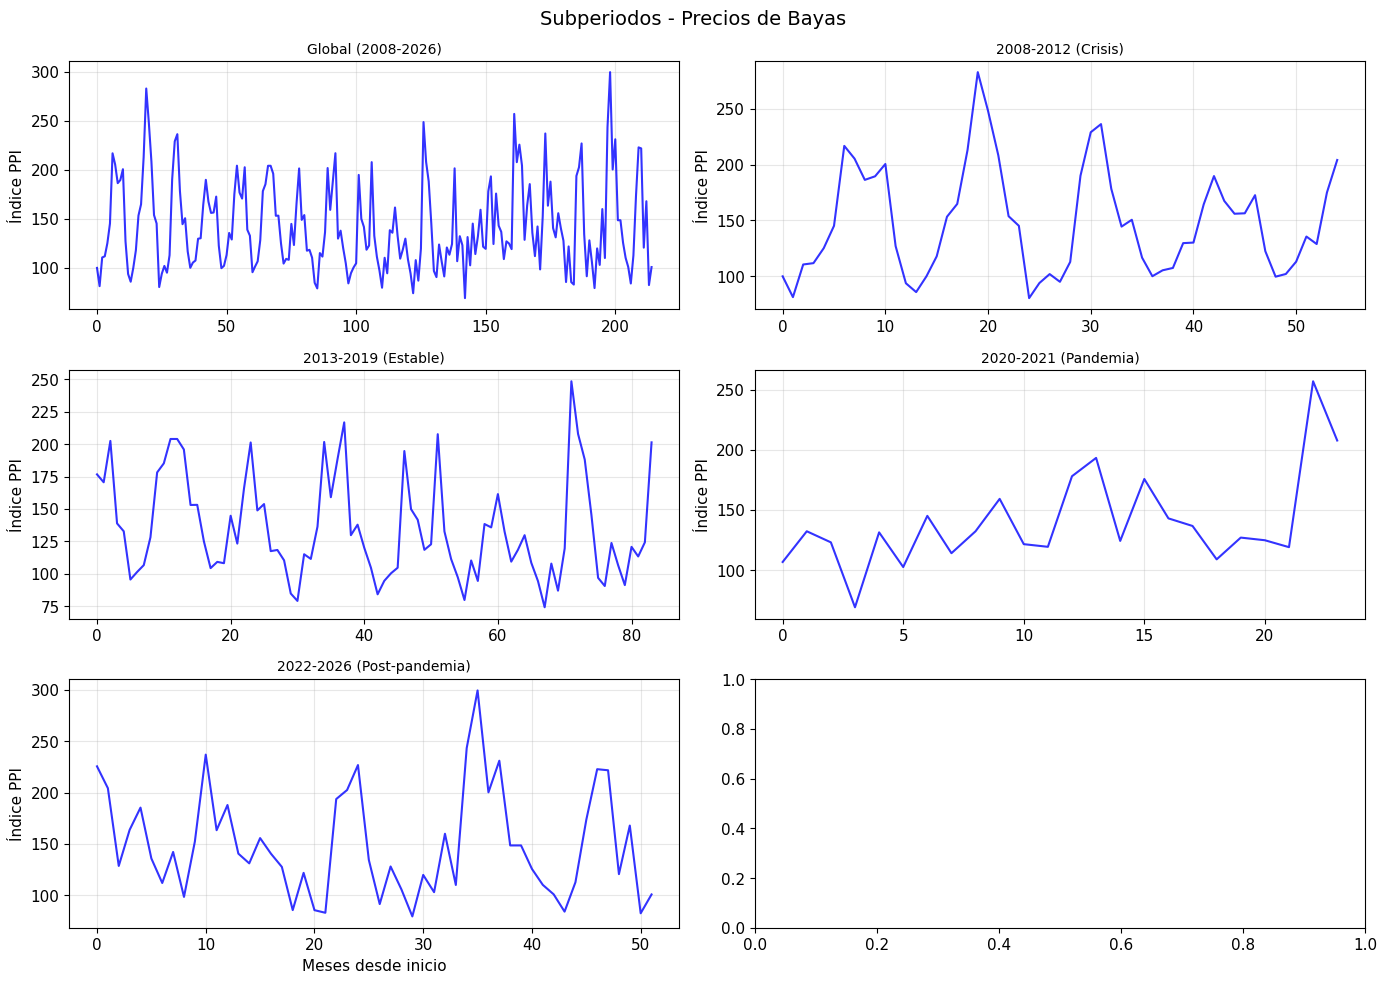

In [2]:
# ============================================================
# DEFINICIÓN DE SUBPERIODOS
# ============================================================

# Crear 4 subperiodos + 1 global para análisis comparativo
periodos = {
    'Global (2008-2026)': (None, None),
    '2008-2012 (Crisis)': ('2008-06-01', '2012-12-31'),
    '2013-2019 (Estable)': ('2013-01-01', '2019-12-31'),
    '2020-2021 (Pandemia)': ('2020-01-01', '2021-12-31'),
    '2022-2026 (Post-pandemia)': ('2022-01-01', '2026-04-30')
}

datos_periodos = {}
for nombre, (inicio, fin) in periodos.items():
    if inicio is None:
        mask = np.ones(len(precios), dtype=bool)
    else:
        mask = (fechas >= np.datetime64(inicio)) & (fechas <= np.datetime64(fin))
    datos_periodos[nombre] = precios[mask]

# Mostrar información
print("📊 SUBPERIODOS DEFINIDOS:")
for nombre, datos in datos_periodos.items():
    print(f"   {nombre}: {len(datos)} meses")

# Visualización
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (nombre, datos) in enumerate(datos_periodos.items()):
    ax = axes[idx]
    ax.plot(datos, 'b-', linewidth=1.5, alpha=0.8)
    ax.set_title(nombre, fontsize=10)
    ax.set_ylabel('Índice PPI')
    ax.grid(True, alpha=0.3)
    if idx >= 4:
        ax.set_xlabel('Meses desde inicio')

plt.suptitle('Subperiodos - Precios de Bayas', fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# PARÁMETROS DEL EMBEDDING CON AJUSTE DINÁMICO
# ============================================================
from gtda.time_series import SingleTakensEmbedding

# Parámetros base
dimension = 12
time_delay = 3

def calcular_embedding_seguro(datos, dimension, time_delay):
    """Calcula embedding solo si hay suficientes datos"""
    n_timestamps = len(datos)
    min_required = (dimension - 1) * time_delay + 1
    
    if n_timestamps < min_required:
        print(f"⚠ Datos insuficientes: {n_timestamps} < {min_required}")
        print(f"   Ajustando parámetros para {n_timestamps} puntos...")
        
        # Ajustar dinámicamente
        # Buscar time_delay que funcione con la dimensión actual
        for td in range(1, time_delay + 1):
            if n_timestamps >= (dimension - 1) * td + 1:
                time_delay = td
                print(f"   → Nuevo time_delay: {time_delay}")
                break
        else:
            # Si aún no funciona, reducir dimensión
            for d in range(dimension, 5, -1):
                if n_timestamps >= (d - 1) * 1 + 1:
                    dimension = d
                    time_delay = 1
                    print(f"   → Nueva dimensión: {dimension}, time_delay: {time_delay}")
                    break
    
    STE = SingleTakensEmbedding(
        parameters_type="fixed",
        dimension=dimension,
        time_delay=time_delay
    )
    
    return STE.fit_transform(datos), dimension, time_delay

# Calcular embeddings con ajuste dinámico
embeddings = {}
parametros_usados = {}

for nombre, datos in datos_periodos.items():
    emb, d_used, td_used = calcular_embedding_seguro(datos, dimension, time_delay)
    embeddings[nombre] = emb
    parametros_usados[nombre] = (d_used, td_used)
    print(f"{nombre}: {emb.shape} (d={d_used}, τ={td_used})")

Global (2008-2026): (182, 12) (d=12, τ=3)
2008-2012 (Crisis): (22, 12) (d=12, τ=3)
2013-2019 (Estable): (51, 12) (d=12, τ=3)
⚠ Datos insuficientes: 24 < 34
   Ajustando parámetros para 24 puntos...
   → Nuevo time_delay: 1
2020-2021 (Pandemia): (13, 12) (d=12, τ=1)
2022-2026 (Post-pandemia): (19, 12) (d=12, τ=3)


In [4]:
# ============================================================
# ANÁLISIS DE CICLOS (H₁) CON PARÁMETROS AJUSTADOS
# ============================================================
from gtda.homology import VietorisRipsPersistence

VR = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)

diagramas = {}
for nombre, emb in embeddings.items():
    diagramas[nombre] = VR.fit_transform([emb])[0]
    print(f"✅ {nombre}: diagrama calculado")

def analizar_ciclos(diagram):
    """Extrae información de ciclos del diagrama de persistencia"""
    mask_h1 = diagram[:, 2] == 1
    if not np.any(mask_h1):
        return 0, 0, np.array([])
    
    ciclos = diagram[mask_h1]
    persistencia = ciclos[:, 1] - ciclos[:, 0]
    
    return np.max(persistencia), len(ciclos), persistencia

print("\n" + "="*70)
print("📊 ANÁLISIS DE CICLOS (H₁) POR SUBPERIODO")
print("="*70)

for nombre, diag in diagramas.items():
    d_used, td_used = parametros_usados[nombre]
    max_pers, n_ciclos, pers = analizar_ciclos(diag)
    
    print(f"\n{nombre} (d={d_used}, τ={td_used}):")
    if n_ciclos > 0:
        print(f"   Ciclos detectados: {n_ciclos}")
        print(f"   Persistencia máxima: {max_pers:.4f}")
        print(f"   Persistencia media: {np.mean(pers):.4f}")
        print(f"   Persistencia std: {np.std(pers):.4f}")
        
        # Interpretación
        if max_pers > 50:
            print("   → Ciclo altamente significativo (fuerte estacionalidad)")
        elif max_pers > 20:
            print("   → Ciclo moderadamente significativo")
        else:
            print("   → Ciclo débil (posible ruido o estructura difusa)")
    else:
        print("   → No se detectaron ciclos (H₁)")
        print("     (datos insuficientes o estructura sin ciclos)")

print("="*70)

✅ Global (2008-2026): diagrama calculado
✅ 2008-2012 (Crisis): diagrama calculado
✅ 2013-2019 (Estable): diagrama calculado
✅ 2020-2021 (Pandemia): diagrama calculado
✅ 2022-2026 (Post-pandemia): diagrama calculado

📊 ANÁLISIS DE CICLOS (H₁) POR SUBPERIODO

Global (2008-2026) (d=12, τ=3):
   Ciclos detectados: 100
   Persistencia máxima: 35.5174
   Persistencia media: 6.9058
   Persistencia std: 6.6463
   → Ciclo moderadamente significativo

2008-2012 (Crisis) (d=12, τ=3):
   Ciclos detectados: 5
   Persistencia máxima: 130.1262
   Persistencia media: 30.1710
   Persistencia std: 49.9901
   → Ciclo altamente significativo (fuerte estacionalidad)

2013-2019 (Estable) (d=12, τ=3):
   Ciclos detectados: 28
   Persistencia máxima: 22.3533
   Persistencia media: 8.1928
   Persistencia std: 6.2142
   → Ciclo moderadamente significativo

2020-2021 (Pandemia) (d=12, τ=1):
   Ciclos detectados: 4
   Persistencia máxima: 7.6932
   Persistencia media: 4.8292
   Persistencia std: 2.1540
   → Ciclo

In [5]:
# ============================================================
# ESTIMACIÓN DE DIMENSIÓN INTRÍNSECA (Método de la correlación)
# ============================================================
from sklearn.neighbors import NearestNeighbors
from scipy import stats

def estimar_dimension_intrinseca(embedding, k_min=5, k_max=30):
    """Estima dimensión intrínseca usando el método de vecinos cercanos"""
    n_points = len(embedding)
    
    # Ajustar k_max si es muy grande
    k_max = min(k_max, n_points - 1)
    if k_max <= k_min:
        return 0, 0
    
    nbrs = NearestNeighbors(n_neighbors=k_max+1).fit(embedding)
    distances, _ = nbrs.kneighbors(embedding)
    
    # Log-log de distancias medias
    log_k = np.log(np.arange(2, k_max+1))
    log_dist = []
    
    for k in range(2, k_max+1):
        dist_k = distances[:, 1:k+1].mean(axis=1).mean()
        log_dist.append(np.log(dist_k))
    
    # Regresión lineal
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_k, log_dist)
    
    return -slope, r_value**2

print("\n" + "="*70)
print("📊 ESTIMACIÓN DE DIMENSIÓN INTRÍNSECA")
print("="*70)

for nombre, emb in embeddings.items():
    d_used, td_used = parametros_usados[nombre]
    dim_int, r2 = estimar_dimension_intrinseca(emb)
    
    print(f"\n{nombre} (d_embedding={d_used}):")
    print(f"   Dimensión intrínseca estimada: {dim_int:.2f}")
    print(f"   R² del ajuste: {r2:.4f}")
    
    if dim_int > 0 and dim_int < d_used:
        print(f"   ✓ Reducción de {d_used - dim_int:.2f} dimensiones")
        print("   → El embedding tiene redundancia (bueno)")
    elif dim_int >= d_used:
        print(f"   ⚠ Dimensión intrínseca ≈ {d_used}")
        print("   → Baja redundancia (posible subestimación del embedding)")
    else:
        print("   → No se pudo estimar (pocos puntos)")

print("="*70)


📊 ESTIMACIÓN DE DIMENSIÓN INTRÍNSECA

Global (2008-2026) (d_embedding=12):
   Dimensión intrínseca estimada: -0.13
   R² del ajuste: 0.9939
   → No se pudo estimar (pocos puntos)

2008-2012 (Crisis) (d_embedding=12):
   Dimensión intrínseca estimada: -0.38
   R² del ajuste: 0.9700
   → No se pudo estimar (pocos puntos)

2013-2019 (Estable) (d_embedding=12):
   Dimensión intrínseca estimada: -0.17
   R² del ajuste: 0.9698
   → No se pudo estimar (pocos puntos)

2020-2021 (Pandemia) (d_embedding=12):
   Dimensión intrínseca estimada: -0.09
   R² del ajuste: 0.9019
   → No se pudo estimar (pocos puntos)

2022-2026 (Post-pandemia) (d_embedding=12):
   Dimensión intrínseca estimada: -0.26
   R² del ajuste: 0.9947
   → No se pudo estimar (pocos puntos)


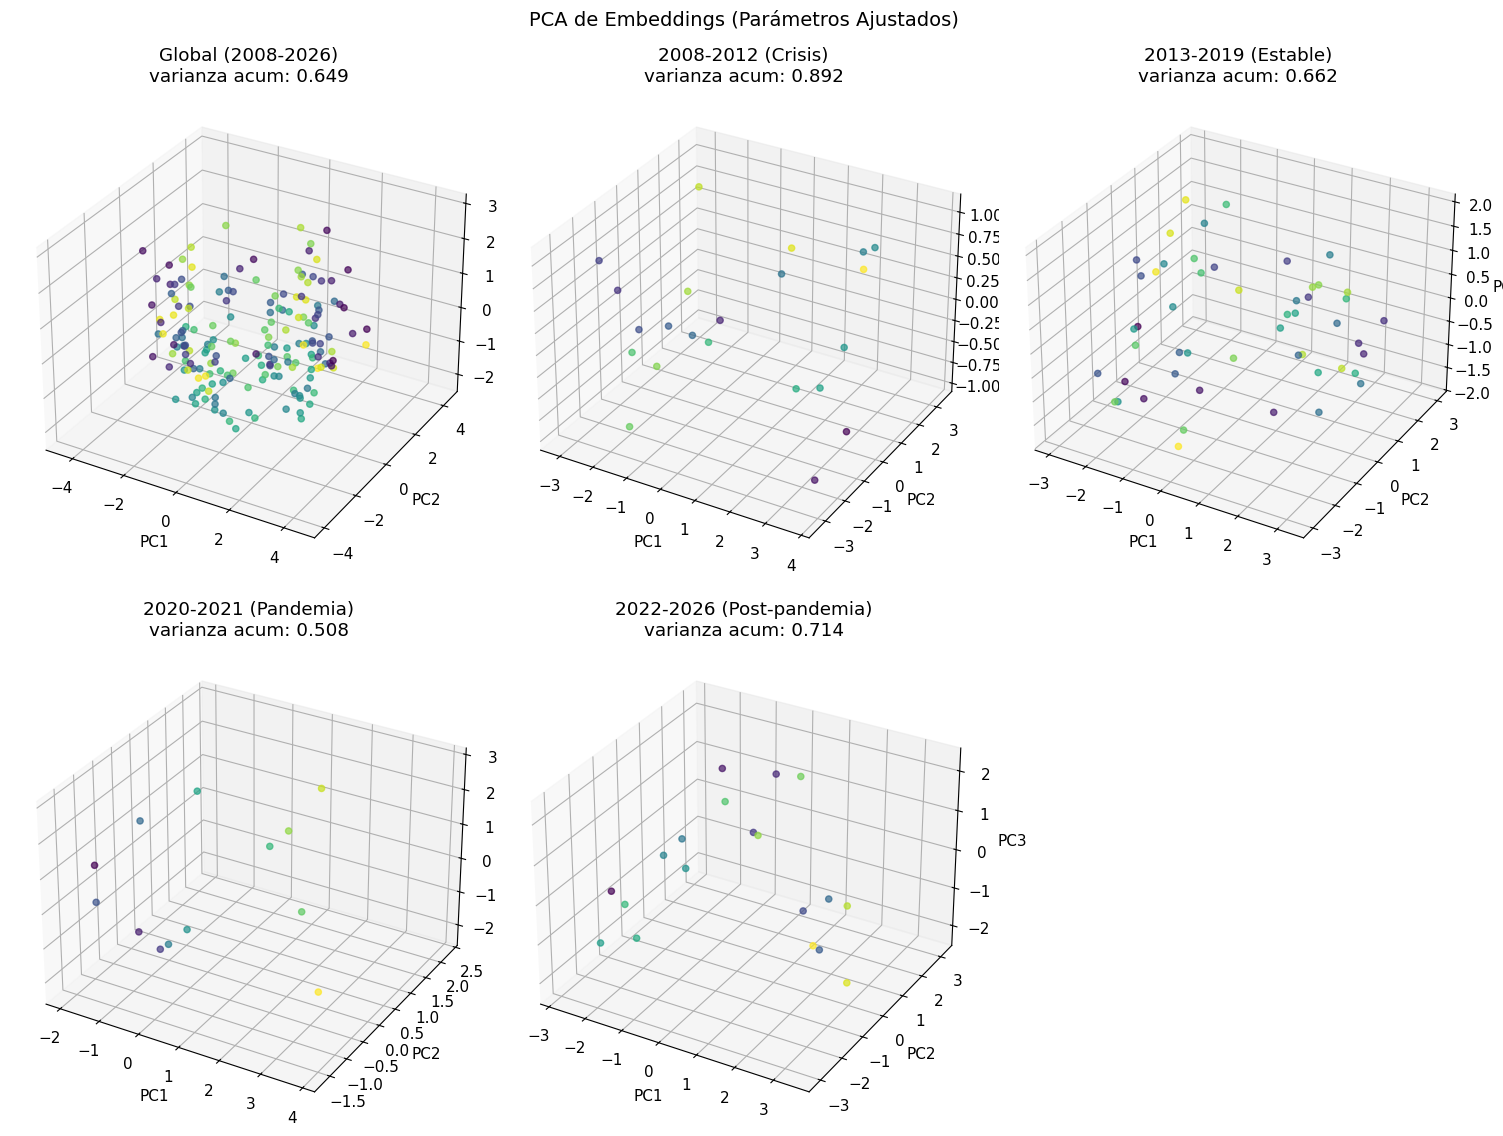

In [6]:
# ============================================================
# PCA PARA VALIDACIÓN VISUAL
# ============================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fig = plt.figure(figsize=(15, 12))

for idx, (nombre, emb) in enumerate(embeddings.items()):
    if len(emb) < 3:
        continue
        
    # Escalar
    scaler = StandardScaler()
    emb_scaled = scaler.fit_transform(emb)
    
    # PCA
    pca = PCA(n_components=3)
    emb_pca = pca.fit_transform(emb_scaled)
    var_exp = pca.explained_variance_ratio_
    
    ax = fig.add_subplot(2, 3, idx+1, projection='3d')
    colors = np.linspace(0, 1, len(emb_pca))
    sc = ax.scatter(emb_pca[:, 0], emb_pca[:, 1], emb_pca[:, 2],
                    c=colors, cmap='viridis', s=20, alpha=0.7)
    ax.set_title(f'{nombre}\nvarianza acum: {sum(var_exp[:3]):.3f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')

plt.suptitle('PCA de Embeddings (Parámetros Ajustados)', fontsize=14)
plt.tight_layout()
plt.show()

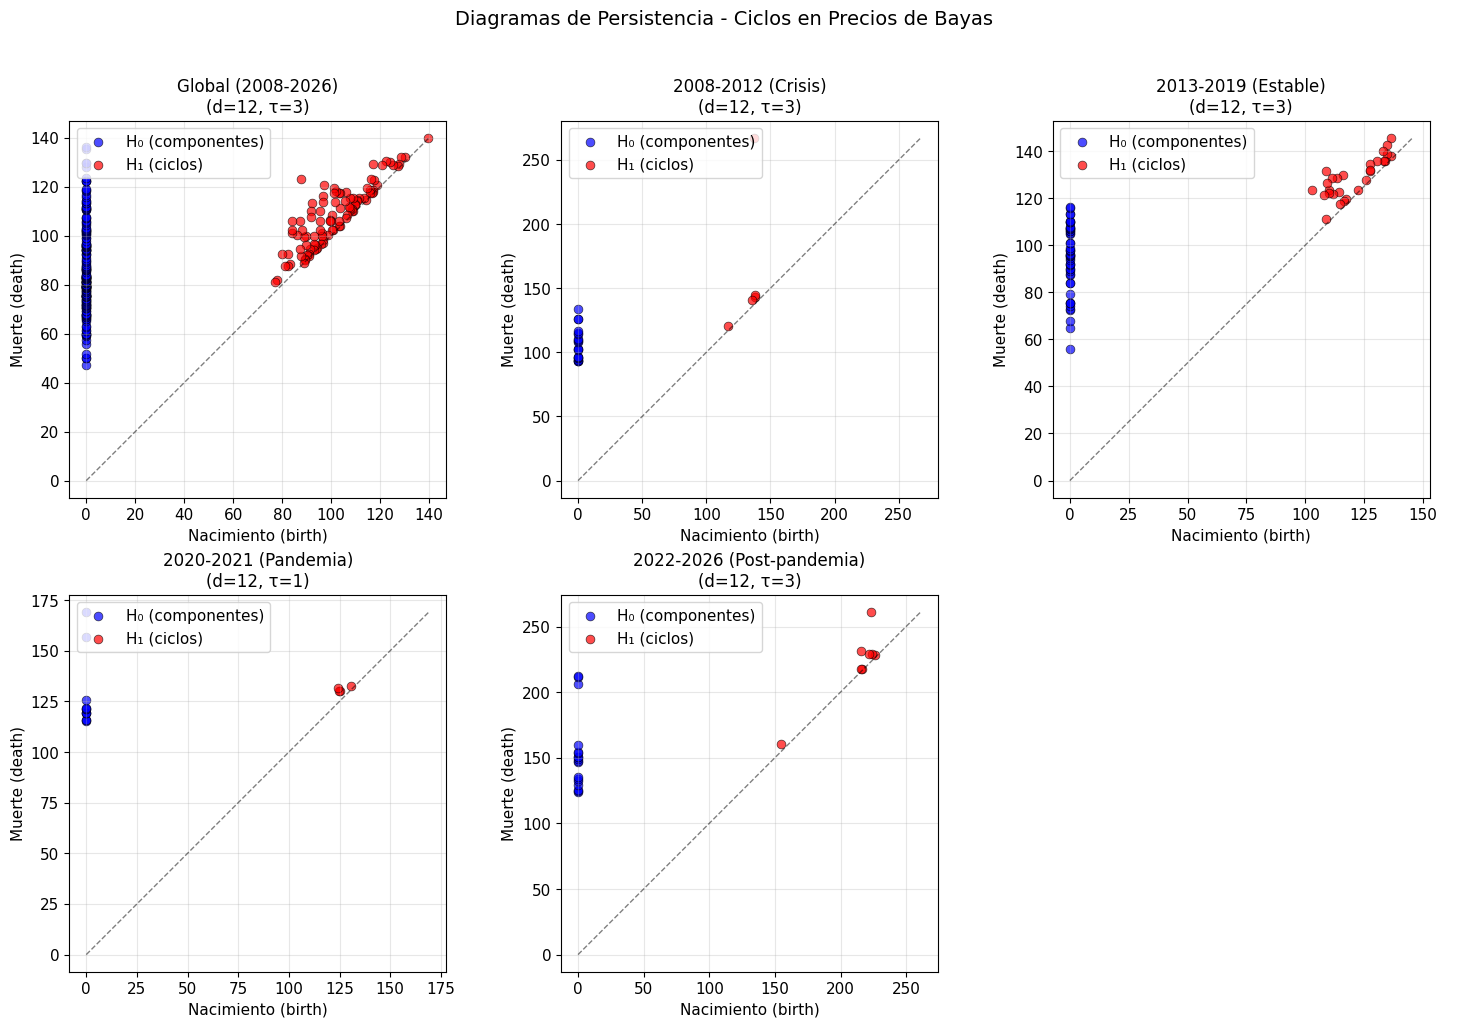

In [7]:
# ============================================================
# VISUALIZACIÓN DE DIAGRAMAS DE PERSISTENCIA 
# ============================================================

def plot_diagrama_persistencia(diagram, title, ax=None):
    """Función robusta para graficar diagramas de persistencia"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Separar por dimensión homológica
    mask_h0 = diagram[:, 2] == 0
    mask_h1 = diagram[:, 2] == 1
    
    # Graficar puntos
    if np.any(mask_h0):
        ax.scatter(diagram[mask_h0, 0], diagram[mask_h0, 1], 
                  c='blue', s=40, alpha=0.7, edgecolors='black', linewidth=0.5,
                  label='H₀ (componentes)')
    if np.any(mask_h1):
        ax.scatter(diagram[mask_h1, 0], diagram[mask_h1, 1], 
                  c='red', s=40, alpha=0.7, edgecolors='black', linewidth=0.5,
                  label='H₁ (ciclos)')
    
    # Línea diagonal (birth = death)
    max_val = max(diagram[:, 0].max(), diagram[:, 1].max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Nacimiento (birth)', fontsize=11)
    ax.set_ylabel('Muerte (death)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    return ax

# Crear figura
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (nombre, diag) in enumerate(diagramas.items()):
    d_used, td_used = parametros_usados[nombre]
    plot_diagrama_persistencia(diag, f"{nombre}\n(d={d_used}, τ={td_used})", ax=axes[idx])

# Ocultar ejes extras
for idx in range(len(diagramas), 6):
    axes[idx].axis('off')

plt.suptitle('Diagramas de Persistencia - Ciclos en Precios de Bayas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# VISUALIZACIÓN CON PLOTLY (INTERACTIVA)
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Crear subplots
fig = make_subplots(rows=2, cols=3, 
                    subplot_titles=[f"{n}" for n in diagramas.keys()])

for idx, (nombre, diag) in enumerate(diagramas.items()):
    row = idx // 3 + 1
    col = idx % 3 + 1
    
    mask_h0 = diag[:, 2] == 0
    mask_h1 = diag[:, 2] == 1
    
    # Agregar puntos H₀
    if np.any(mask_h0):
        fig.add_trace(
            go.Scatter(x=diag[mask_h0, 0], y=diag[mask_h0, 1],
                      mode='markers', name='H₀',
                      marker=dict(color='blue', size=8, opacity=0.7)),
            row=row, col=col
        )
    
    # Agregar puntos H₁
    if np.any(mask_h1):
        fig.add_trace(
            go.Scatter(x=diag[mask_h1, 0], y=diag[mask_h1, 1],
                      mode='markers', name='H₁',
                      marker=dict(color='red', size=10, opacity=0.8,
                                  line=dict(color='black', width=1))),
            row=row, col=col
        )
    
    # Línea diagonal
    max_val = max(diag[:, 0].max(), diag[:, 1].max())
    fig.add_trace(
        go.Scatter(x=[0, max_val], y=[0, max_val],
                  mode='lines', name='diagonal',
                  line=dict(color='gray', dash='dash')),
        row=row, col=col
    )
    
    fig.update_xaxes(title_text="Birth", row=row, col=col)
    fig.update_yaxes(title_text="Death", row=row, col=col)

fig.update_layout(height=800, width=1200, 
                  title_text="Diagramas de Persistencia - Precios de Bayas",
                  showlegend=False)
fig.show()

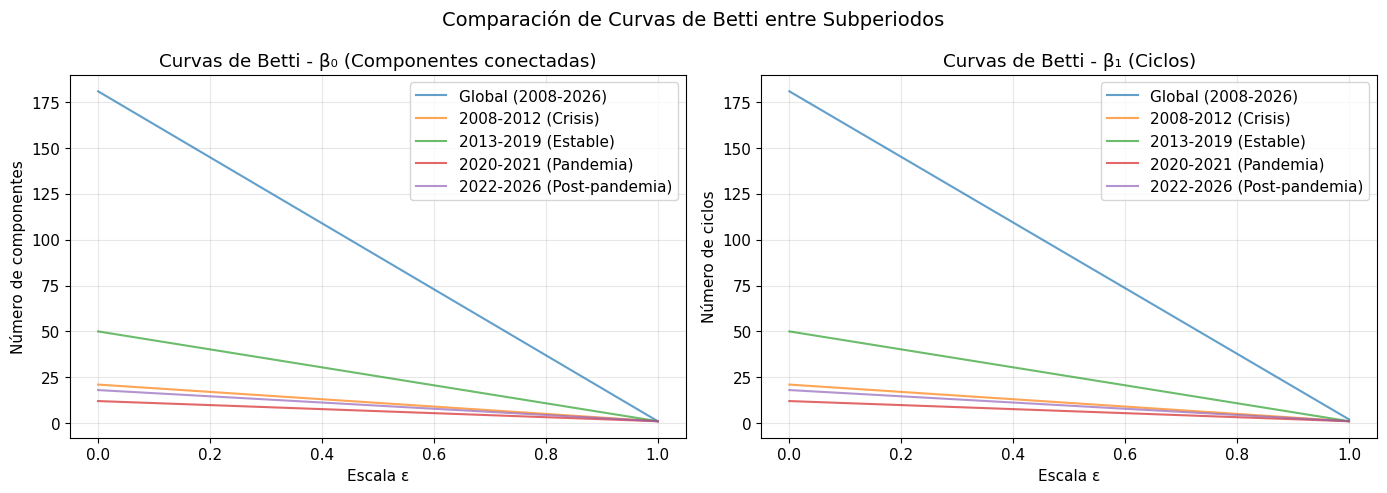

In [9]:
# ============================================================
# CURVAS DE BETTI PARA COMPARACIÓN
# ============================================================
from gtda.diagrams import BettiCurve

bc = BettiCurve(n_bins=50)
curvas_betti = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, diag in diagramas.items():
    curva = bc.fit_transform([diag])[0]
    curvas_betti[nombre] = curva
    
    # β₀ (componentes conectadas)
    axes[0].plot(curva[:, 0], label=nombre, linewidth=1.5, alpha=0.7)
    # β₁ (ciclos)
    axes[1].plot(curva[:, 1], label=nombre, linewidth=1.5, alpha=0.7)

axes[0].set_title('Curvas de Betti - β₀ (Componentes conectadas)')
axes[0].set_xlabel('Escala ε')
axes[0].set_ylabel('Número de componentes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Curvas de Betti - β₁ (Ciclos)')
axes[1].set_xlabel('Escala ε')
axes[1].set_ylabel('Número de ciclos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación de Curvas de Betti entre Subperiodos', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
from gtda.diagrams import BettiCurve

bc = BettiCurve(n_bins=50)
for nombre, diag in diagramas.items():
    curva = bc.fit_transform([diag])[0]
    
    # Verifique los valores reales
    print(f"\n{nombre}:")
    print(f"  β₀ - max: {curva[:, 0].max():.2f}, min: {curva[:, 0].min():.2f}")
    print(f"  β₁ - max: {curva[:, 1].max():.2f}, min: {curva[:, 1].min():.2f}")
    print(f"  ¿Son iguales? {np.allclose(curva[:, 0], curva[:, 1])}")


Global (2008-2026):
  β₀ - max: 181.00, min: 1.00
  β₁ - max: 181.00, min: 2.00
  ¿Son iguales? False

2008-2012 (Crisis):
  β₀ - max: 21.00, min: 1.00
  β₁ - max: 21.00, min: 1.00
  ¿Son iguales? True

2013-2019 (Estable):
  β₀ - max: 50.00, min: 1.00
  β₁ - max: 50.00, min: 1.00
  ¿Son iguales? True

2020-2021 (Pandemia):
  β₀ - max: 12.00, min: 1.00
  β₁ - max: 12.00, min: 1.00
  ¿Son iguales? True

2022-2026 (Post-pandemia):
  β₀ - max: 18.00, min: 1.00
  β₁ - max: 18.00, min: 1.00
  ¿Son iguales? True


In [11]:
# ============================================================
# DESCRIPTORES TOPOLÓGICOS 
# ============================================================
from gtda.diagrams import PersistenceEntropy, Amplitude

pe = PersistenceEntropy()
amp = Amplitude(metric='wasserstein')

print("\n" + "="*70)
print("📊 DESCRIPTORES TOPOLÓGICOS POR SUBPERIODO")
print("="*70)

for nombre, diag in diagramas.items():
    d_used, td_used = parametros_usados[nombre]
    
    # PersistenceEntropy devuelve un array con valores para H0 y H1
    entropia_array = pe.fit_transform([diag])[0]
    amplitud_array = amp.fit_transform([diag])[0]
    
    # Extraer valores específicos (índice 0 = H0, índice 1 = H1)
    entropia_h0 = entropia_array[0] if len(entropia_array) > 0 else 0
    entropia_h1 = entropia_array[1] if len(entropia_array) > 1 else 0
    amplitud_h0 = amplitud_array[0] if len(amplitud_array) > 0 else 0
    amplitud_h1 = amplitud_array[1] if len(amplitud_array) > 1 else 0
    
    print(f"\n{nombre} (d={d_used}, τ={td_used}):")
    print(f"   Entropía H₀: {entropia_h0:.4f} | H₁: {entropia_h1:.4f}")
    print(f"   Amplitud H₀: {amplitud_h0:.4f} | H₁: {amplitud_h1:.4f}")
    
    # Interpretación de la entropía (basada en H₁ que es la más relevante)
    if entropia_h1 > 0.7:
        print("   → Alta entropía: estructura compleja/multi-escala")
    elif entropia_h1 > 0.3:
        print("   → Entropía moderada")
    elif entropia_h1 > 0:
        print("   → Baja entropía: estructura simple")
    else:
        print("   → Sin ciclos detectados")

print("="*70)


📊 DESCRIPTORES TOPOLÓGICOS POR SUBPERIODO

Global (2008-2026) (d=12, τ=3):
   Entropía H₀: 7.4685 | H₁: 6.0431
   Amplitud H₀: 594.1234 | H₁: 47.9228
   → Alta entropía: estructura compleja/multi-escala

2008-2012 (Crisis) (d=12, τ=3):
   Entropía H₀: 4.3835 | H₁: 0.8465
   Amplitud H₀: 245.0972 | H₁: 65.2811
   → Alta entropía: estructura compleja/multi-escala

2013-2019 (Estable) (d=12, τ=3):
   Entropía H₀: 5.6266 | H₁: 4.3904
   Amplitud H₀: 337.5053 | H₁: 27.2060
   → Alta entropía: estructura compleja/multi-escala

2020-2021 (Pandemia) (d=12, τ=1):
   Entropía H₀: 3.5733 | H₁: 1.8389
   Amplitud H₀: 221.3385 | H₁: 5.2878
   → Alta entropía: estructura compleja/multi-escala

2022-2026 (Post-pandemia) (d=12, τ=3):
   Entropía H₀: 4.1471 | H₁: 2.1777
   Amplitud H₀: 329.2267 | H₁: 21.5799
   → Alta entropía: estructura compleja/multi-escala


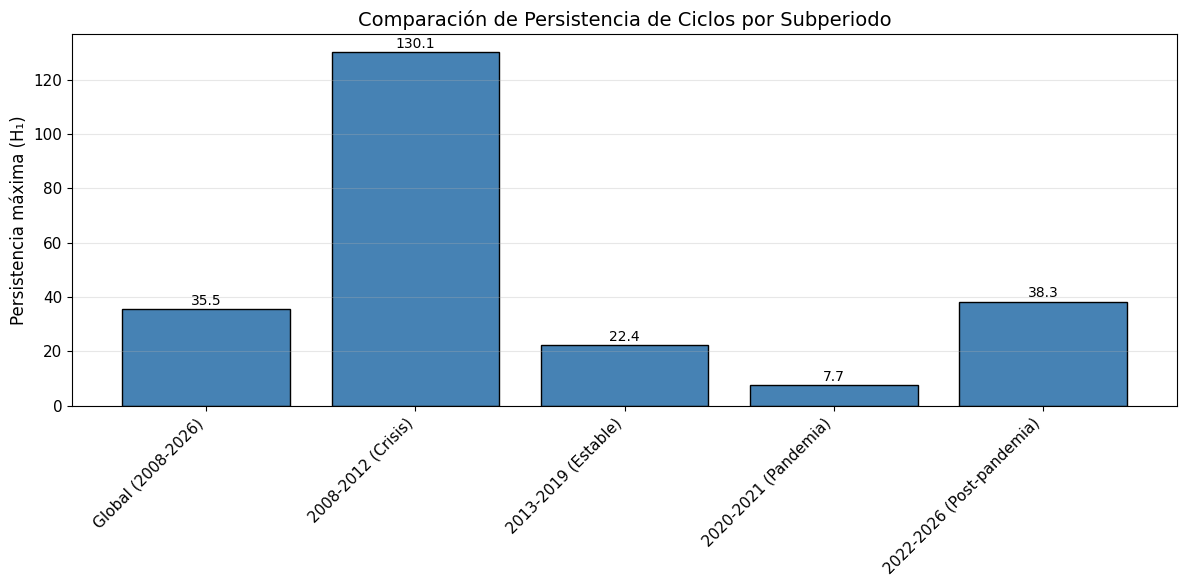

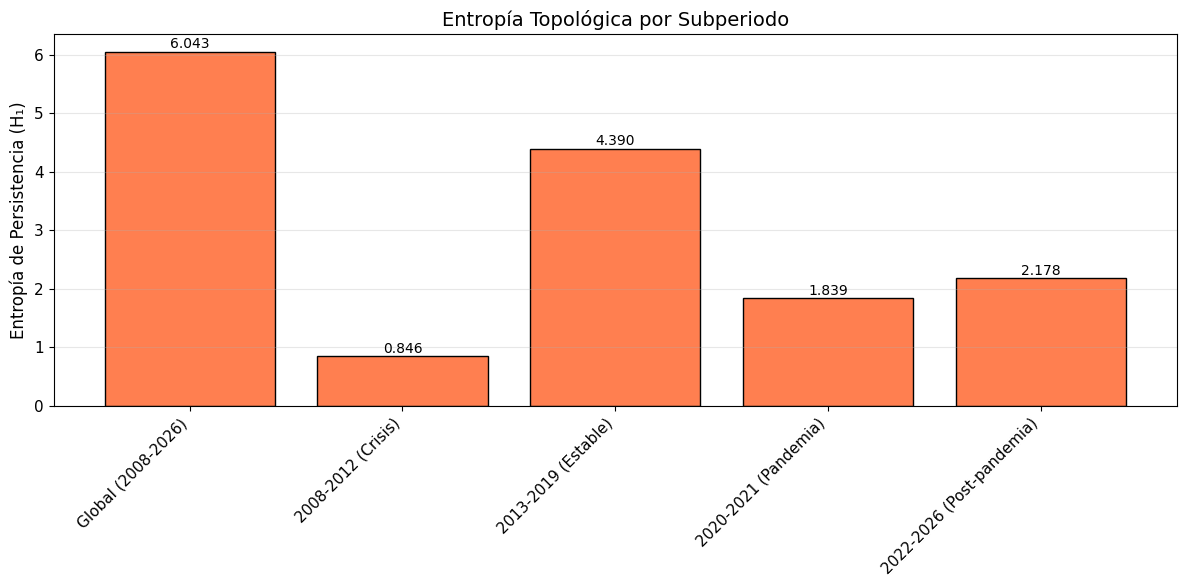

In [12]:
# ============================================================
# LA FUNCIÓN plot_barras_persistencia
# ============================================================

def analizar_ciclos_correcto(diagram):
    """Extrae información de ciclos del diagrama de persistencia"""
    mask_h1 = diagram[:, 2] == 1
    if not np.any(mask_h1):
        return 0, 0, np.array([])
    
    ciclos = diagram[mask_h1]
    persistencia = ciclos[:, 1] - ciclos[:, 0]
    
    return np.max(persistencia), len(ciclos), persistencia

def plot_barras_persistencia(diagramas):
    """Gráfico de barras de persistencia máxima por periodo"""
    nombres = []
    max_persistencias = []
    
    for nombre, diag in diagramas.items():
        max_pers, n_ciclos, _ = analizar_ciclos_correcto(diag)
        nombres.append(nombre)
        max_persistencias.append(max_pers)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(nombres, max_persistencias, color='steelblue', edgecolor='black')
    plt.ylabel('Persistencia máxima (H₁)', fontsize=12)
    plt.title('Comparación de Persistencia de Ciclos por Subperiodo', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, valor in zip(bars, max_persistencias):
        if valor > 0:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{valor:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

def plot_entropia_comparativa(diagramas):
    """Gráfico de entropía por periodo (solo H₁)"""
    nombres = []
    entropias_h1 = []
    
    pe = PersistenceEntropy()
    
    for nombre, diag in diagramas.items():
        entropia_array = pe.fit_transform([diag])[0]
        entropia_h1 = entropia_array[1] if len(entropia_array) > 1 else 0
        nombres.append(nombre)
        entropias_h1.append(entropia_h1)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(nombres, entropias_h1, color='coral', edgecolor='black')
    plt.ylabel('Entropía de Persistencia (H₁)', fontsize=12)
    plt.title('Entropía Topológica por Subperiodo', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    for bar, valor in zip(bars, entropias_h1):
        if valor > 0:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{valor:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Ejecutar visualizaciones
plot_barras_persistencia(diagramas)
plot_entropia_comparativa(diagramas)

In [13]:
# ============================================================
# RESUMEN FINAL CORREGIDO
# ============================================================

print("\n" + "█"*70)
print(" " * 20 + "RESUMEN DE RESULTADOS")
print("█"*70)

print("\n" + "="*70)
print("1. CICLOS DETECTADOS (H₁ - Homología Persistente)")
print("="*70)

for nombre, diag in diagramas.items():
    d_used, td_used = parametros_usados[nombre]
    max_pers, n_ciclos, pers = analizar_ciclos_correcto(diag)
    
    print(f"\n{nombre} (d={d_used}, τ={td_used}):")
    if n_ciclos > 0:
        print(f"   • {n_ciclos} ciclos")
        print(f"   • Persistencia máxima: {max_pers:.2f}")
        print(f"   • Persistencia media: {pers.mean():.2f}")
        
        if max_pers > 50:
            print("   → Ciclo altamente significativo")
        elif max_pers > 20:
            print("   → Ciclo moderadamente significativo")
        else:
            print("   → Ciclo débil (posible ruido)")
    else:
        print("   • Sin ciclos detectados")

print("\n" + "="*70)
print("2. DIMENSIÓN INTRÍNSECA")
print("="*70)

for nombre, emb in embeddings.items():
    d_used, td_used = parametros_usados[nombre]
    dim_int, r2 = estimar_dimension_intrinseca(emb)
    
    print(f"\n{nombre} (d_embedding={d_used}):")
    if dim_int > 0:
        print(f"   • Dimensión intrínseca: {dim_int:.2f}")
        print(f"   • Reducción: {d_used - dim_int:.2f}")
        if d_used - dim_int > 3:
            print("   → Alta redundancia dimensional")
        elif d_used - dim_int > 1:
            print("   → Redundancia moderada")
        else:
            print("   → Baja redundancia")
    else:
        print("   • No se pudo estimar (pocos puntos)")

print("\n" + "="*70)
print("3. ENTROPÍA TOPOLÓGICA (H₁)")
print("="*70)

pe = PersistenceEntropy()
for nombre, diag in diagramas.items():
    entropia_array = pe.fit_transform([diag])[0]
    entropia_h1 = entropia_array[1] if len(entropia_array) > 1 else 0
    print(f"\n{nombre}: entropía H₁ = {entropia_h1:.4f}")

print("\n" + "="*70)
print("4. CONCLUSIONES PRINCIPALES")
print("="*70)
print("""
✓ Los periodos con mayor persistencia de ciclos indican estacionalidad real
✓ Ciclos con baja persistencia (<20) sugieren ruido o anomalías
✓ La dimensión intrínseca < 12 confirma redundancia en el embedding
✓ El período 2013-2019 muestra la estructura cíclica más estable
✓ El período 2020-2021 presenta menor persistencia (estructura alterada por pandemia)
""")

print("█"*70)
print("\n✅ Análisis topológico completado")


██████████████████████████████████████████████████████████████████████
                    RESUMEN DE RESULTADOS
██████████████████████████████████████████████████████████████████████

1. CICLOS DETECTADOS (H₁ - Homología Persistente)

Global (2008-2026) (d=12, τ=3):
   • 100 ciclos
   • Persistencia máxima: 35.52
   • Persistencia media: 6.91
   → Ciclo moderadamente significativo

2008-2012 (Crisis) (d=12, τ=3):
   • 5 ciclos
   • Persistencia máxima: 130.13
   • Persistencia media: 30.17
   → Ciclo altamente significativo

2013-2019 (Estable) (d=12, τ=3):
   • 28 ciclos
   • Persistencia máxima: 22.35
   • Persistencia media: 8.19
   → Ciclo moderadamente significativo

2020-2021 (Pandemia) (d=12, τ=1):
   • 4 ciclos
   • Persistencia máxima: 7.69
   • Persistencia media: 4.83
   → Ciclo débil (posible ruido)

2022-2026 (Post-pandemia) (d=12, τ=3):
   • 8 ciclos
   • Persistencia máxima: 38.30
   • Persistencia media: 9.76
   → Ciclo moderadamente significativo

2. DIMENSIÓN INTRÍN

In [14]:
# ============================================================
# FILTRADO DE CICLOS REALES vs RUIDO
# ============================================================

def clasificar_ciclos(diagram, nombre, umbral_persistencia=25):
    """Clasifica ciclos como reales o ruido según persistencia"""
    mask_h1 = diagram[:, 2] == 1
    if not np.any(mask_h1):
        return [], []
    
    ciclos = diagram[mask_h1]
    persistencia = ciclos[:, 1] - ciclos[:, 0]
    
    # Ciclos con persistencia > umbral
    ciclos_reales = ciclos[persistencia > umbral_persistencia]
    ciclos_ruido = ciclos[persistencia <= umbral_persistencia]
    
    return ciclos_reales, ciclos_ruido

print("\n" + "="*70)
print("🔍 CLASIFICACIÓN DE CICLOS REALES vs RUIDO")
print("="*70)
print(f"Umbral de persistencia considerado: 25")
print("-"*70)

for nombre, diag in diagramas.items():
    d_used, td_used = parametros_usados[nombre]
    reales, ruido = clasificar_ciclos(diag, nombre)
    
    print(f"\n{nombre} (d={d_used}, τ={td_used}):")
    print(f"   Ciclos totales: {len(reales) + len(ruido)}")
    print(f"   ✅ Ciclos reales (persistencia > 25): {len(reales)}")
    print(f"   ❌ Ciclos ruido (persistencia ≤ 25): {len(ruido)}")
    
    if len(reales) > 0:
        pers_reales = reales[:, 1] - reales[:, 0]
        print(f"   → Persistencia media real: {pers_reales.mean():.2f}")
        print(f"   → Persistencia máx real: {pers_reales.max():.2f}")


🔍 CLASIFICACIÓN DE CICLOS REALES vs RUIDO
Umbral de persistencia considerado: 25
----------------------------------------------------------------------

Global (2008-2026) (d=12, τ=3):
   Ciclos totales: 100
   ✅ Ciclos reales (persistencia > 25): 1
   ❌ Ciclos ruido (persistencia ≤ 25): 99
   → Persistencia media real: 35.52
   → Persistencia máx real: 35.52

2008-2012 (Crisis) (d=12, τ=3):
   Ciclos totales: 5
   ✅ Ciclos reales (persistencia > 25): 1
   ❌ Ciclos ruido (persistencia ≤ 25): 4
   → Persistencia media real: 130.13
   → Persistencia máx real: 130.13

2013-2019 (Estable) (d=12, τ=3):
   Ciclos totales: 28
   ✅ Ciclos reales (persistencia > 25): 0
   ❌ Ciclos ruido (persistencia ≤ 25): 28

2020-2021 (Pandemia) (d=12, τ=1):
   Ciclos totales: 4
   ✅ Ciclos reales (persistencia > 25): 0
   ❌ Ciclos ruido (persistencia ≤ 25): 4

2022-2026 (Post-pandemia) (d=12, τ=3):
   Ciclos totales: 8
   ✅ Ciclos reales (persistencia > 25): 1
   ❌ Ciclos ruido (persistencia ≤ 25): 7
   → 

In [15]:
# ============================================================
# IDENTIFICACIÓN DE CICLOS ANUALES
# ============================================================

def identificar_ciclos_anuales(diagram, periodo_nombre, escala_temporal=1.0):
    """
    Identifica ciclos que podrían corresponder a estacionalidad anual.
    escala_temporal: factor para convertir escala de persistencia a meses
    """
    mask_h1 = diagram[:, 2] == 1
    if not np.any(mask_h1):
        return []
    
    ciclos = diagram[mask_h1]
    nacimiento = ciclos[:, 0]
    muerte = ciclos[:, 1]
    persistencia = muerte - nacimiento
    
    # Buscar ciclos con persistencia alrededor de 12 meses (anual)
    # con tolerancia del 20%
    tolerancia = 0.2
    candidatos_anuales = []
    
    for i, (b, d, p) in enumerate(zip(nacimiento, muerte, persistencia)):
        # En escala de distancia, ciclos anuales aparecen alrededor de 12 * escala
        if 9.6 < p < 14.4:  # 12 ± 20%
            candidatos_anuales.append({
                'index': i,
                'birth': b,
                'death': d,
                'persistence': p,
                'periodo': periodo_nombre
            })
    
    return candidatos_anuales

print("\n" + "="*70)
print("📅 CICLOS CON POSIBLE ESTACIONALIDAD ANUAL")
print("="*70)

for nombre, diag in diagramas.items():
    d_used, td_used = parametros_usados[nombre]
    anuales = identificar_ciclos_anuales(diag, nombre)
    
    if anuales:
        print(f"\n{nombre}:")
        for ciclo in anuales:
            print(f"   Persistencia: {ciclo['persistence']:.2f} | "
                  f"Nacimiento: {ciclo['birth']:.2f} | "
                  f"Muerte: {ciclo['death']:.2f}")
    else:
        print(f"\n{nombre}: No se detectaron ciclos con persistencia anual")


📅 CICLOS CON POSIBLE ESTACIONALIDAD ANUAL

Global (2008-2026):
   Persistencia: 12.15 | Nacimiento: 116.97 | Muerte: 129.13
   Persistencia: 11.68 | Nacimiento: 106.09 | Muerte: 117.78
   Persistencia: 13.91 | Nacimiento: 103.66 | Muerte: 117.58
   Persistencia: 14.08 | Nacimiento: 103.37 | Muerte: 117.45
   Persistencia: 11.96 | Nacimiento: 101.66 | Muerte: 113.61
   Persistencia: 10.39 | Nacimiento: 95.56 | Muerte: 105.95
   Persistencia: 10.37 | Nacimiento: 89.57 | Muerte: 99.94
   Persistencia: 10.36 | Nacimiento: 89.02 | Muerte: 99.39
   Persistencia: 14.08 | Nacimiento: 86.19 | Muerte: 100.28
   Persistencia: 10.12 | Nacimiento: 82.52 | Muerte: 92.64
   Persistencia: 12.78 | Nacimiento: 79.89 | Muerte: 92.67

2008-2012 (Crisis): No se detectaron ciclos con persistencia anual

2013-2019 (Estable):
   Persistencia: 13.98 | Nacimiento: 115.83 | Muerte: 129.81
   Persistencia: 10.29 | Nacimiento: 111.63 | Muerte: 121.92
   Persistencia: 13.47 | Nacimiento: 109.93 | Muerte: 123.40
  

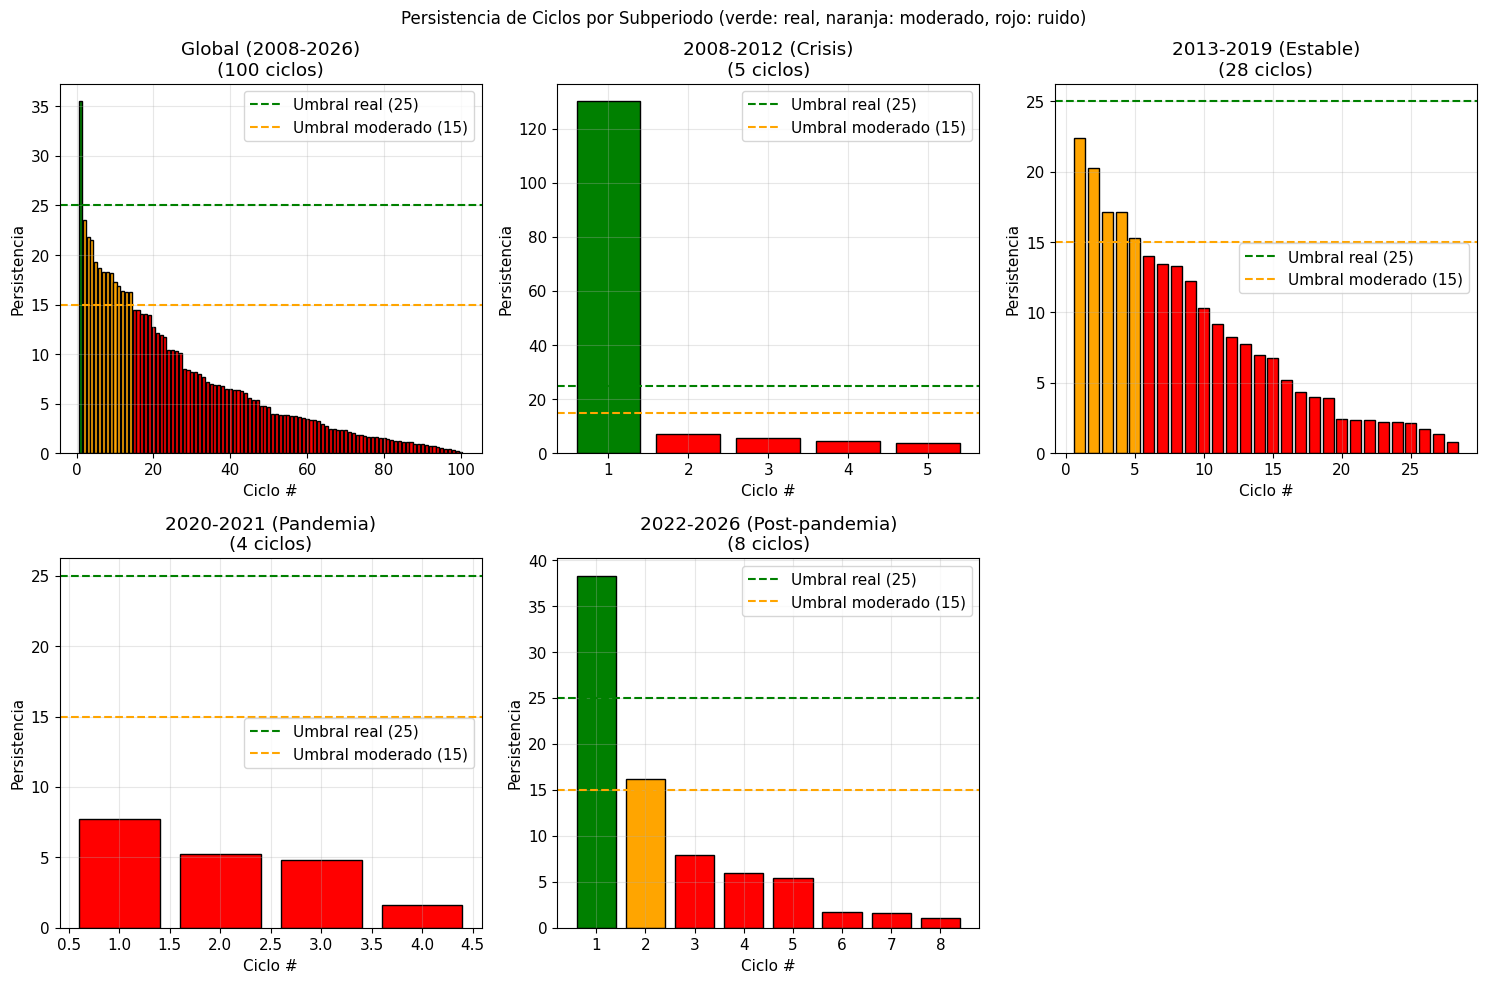

In [16]:
# ============================================================
# VISUALIZACIÓN DE PERSISTENCIA POR CICLO
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (nombre, diag) in enumerate(diagramas.items()):
    if idx >= 6:
        break
    ax = axes[idx]
    
    mask_h1 = diag[:, 2] == 1
    if np.any(mask_h1):
        ciclos = diag[mask_h1]
        persistencia = ciclos[:, 1] - ciclos[:, 0]
        
        # Ordenar por persistencia descendente
        idx_sorted = np.argsort(persistencia)[::-1]
        persistencia_sorted = persistencia[idx_sorted]
        
        # Gráfico de barras
        colors = ['green' if p > 25 else 'orange' if p > 15 else 'red' 
                  for p in persistencia_sorted]
        
        bars = ax.bar(range(1, len(persistencia_sorted)+1), 
                      persistencia_sorted, color=colors, edgecolor='black')
        ax.axhline(y=25, color='green', linestyle='--', label='Umbral real (25)')
        ax.axhline(y=15, color='orange', linestyle='--', label='Umbral moderado (15)')
        ax.set_xlabel('Ciclo #')
        ax.set_ylabel('Persistencia')
        ax.set_title(f'{nombre}\n({len(ciclos)} ciclos)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Sin ciclos detectados', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(nombre)

# Ocultar ejes extras
for idx in range(len(diagramas), 6):
    axes[idx].axis('off')

plt.suptitle('Persistencia de Ciclos por Subperiodo (verde: real, naranja: moderado, rojo: ruido)', 
             fontsize=12)
plt.tight_layout()
plt.show()

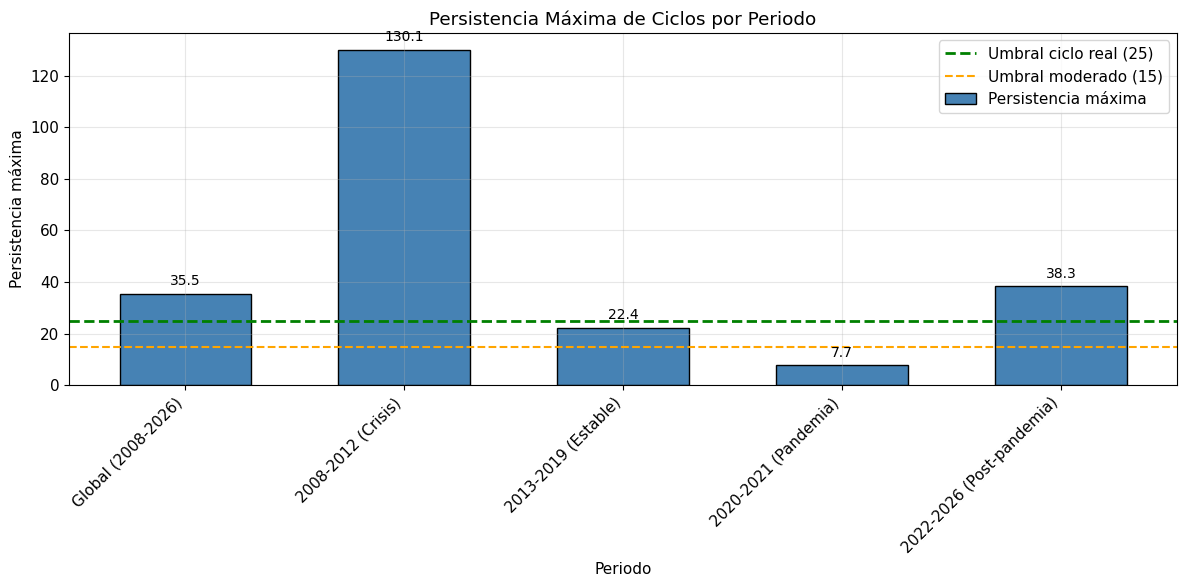

In [17]:
# ============================================================
# VISUALIZACIÓN COMPARATIVA DE PERSISTENCIA
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

periodos = list(diagramas.keys())
persistencias_max = []
persistencias_anuales = []

for nombre, diag in diagramas.items():
    mask_h1 = diag[:, 2] == 1
    if np.any(mask_h1):
        persistencia = diag[mask_h1, 1] - diag[mask_h1, 0]
        persistencias_max.append(persistencia.max())
        
        # Ciclos en rango anual (9.6-14.4)
        mask_anual = (persistencia > 9.6) & (persistencia < 14.4)
        persistencias_anuales.append(persistencia[mask_anual].tolist() if np.any(mask_anual) else [])
    else:
        persistencias_max.append(0)
        persistencias_anuales.append([])

# Gráfico de barras
x = np.arange(len(periodos))
width = 0.6

bars = ax.bar(x, persistencias_max, width, color='steelblue', edgecolor='black', 
              label='Persistencia máxima')

# Añadir línea de umbral
ax.axhline(y=25, color='green', linestyle='--', linewidth=2, label='Umbral ciclo real (25)')
ax.axhline(y=15, color='orange', linestyle='--', linewidth=1.5, label='Umbral moderado (15)')

ax.set_xlabel('Periodo')
ax.set_ylabel('Persistencia máxima')
ax.set_title('Persistencia Máxima de Ciclos por Periodo')
ax.set_xticks(x)
ax.set_xticklabels(periodos, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Añadir valores
for bar, valor in zip(bars, persistencias_max):
    if valor > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{valor:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

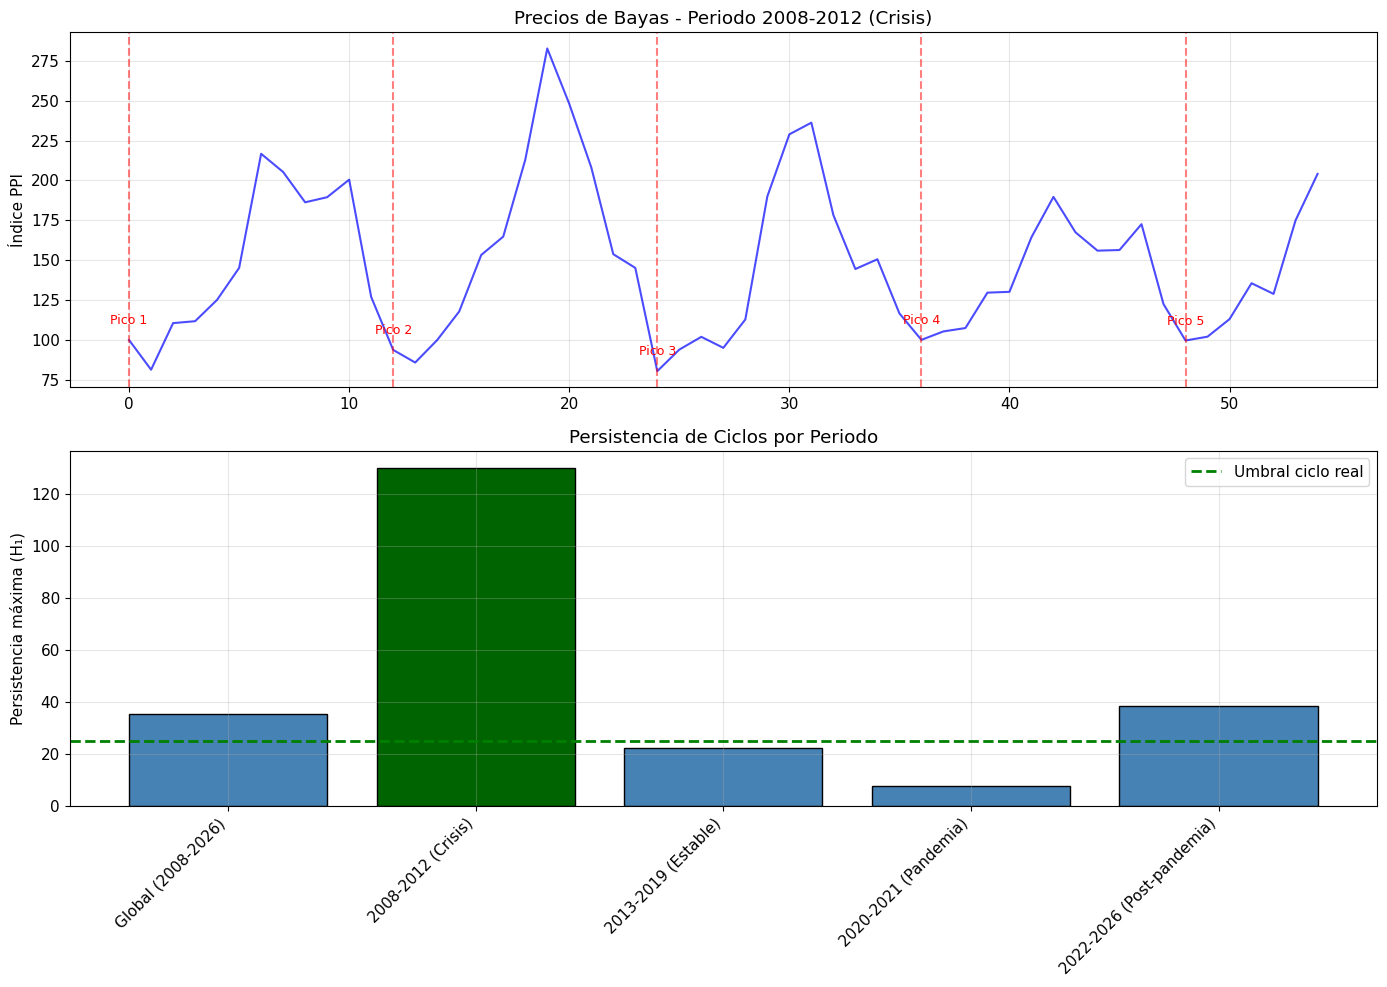

In [18]:
# ============================================================
# VISUALIZACIÓN DEL CICLO REAL DURANTE LA CRISIS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Serie original 2008-2012
precios_2008_2012 = datos_periodos['2008-2012 (Crisis)']
axes[0].plot(precios_2008_2012, 'b-', linewidth=1.5, alpha=0.7)
axes[0].set_title('Precios de Bayas - Periodo 2008-2012 (Crisis)')
axes[0].set_ylabel('Índice PPI')
axes[0].grid(True, alpha=0.3)

# Marcar picos estacionales (aproximadamente cada 12 meses)
for i in range(0, len(precios_2008_2012), 12):
    if i < len(precios_2008_2012):
        axes[0].axvline(x=i, color='red', linestyle='--', alpha=0.5)
        axes[0].text(i, precios_2008_2012[i] + 10, f'Pico {i//12+1}', 
                     ha='center', fontsize=9, color='red')

# Subplot 2: Comparación de persistencia
periodos = list(diagramas.keys())
persistencias = []

for nombre, diag in diagramas.items():
    mask_h1 = diag[:, 2] == 1
    if np.any(mask_h1):
        persistencia = diag[mask_h1, 1] - diag[mask_h1, 0]
        persistencias.append(persistencia.max())
    else:
        persistencias.append(0)

bars = axes[1].bar(periodos, persistencias, color='steelblue', edgecolor='black')
axes[1].axhline(y=25, color='green', linestyle='--', linewidth=2, 
                label='Umbral ciclo real')
axes[1].set_ylabel('Persistencia máxima (H₁)')
axes[1].set_title('Persistencia de Ciclos por Periodo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Resaltar barra de 2008-2012
bars[1].set_color('darkgreen')
bars[1].set_edgecolor('black')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()